In [18]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import joblib
import matplotlib.pyplot as plt

In [19]:
# Load datasets
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_val   = np.load("X_val.npy")
y_val   = np.load("y_val.npy")
X_test  = np.load("X_test.npy")
y_test  = np.load("y_test.npy")

# Load scaler
scaler = joblib.load("scaler.pkl")

In [20]:
print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

Shapes:
X_train: (41321, 24, 1) y_train: (41321, 4)
X_val  : (8759, 24, 1) y_val  : (8759, 4)
X_test : (8872, 24, 1) y_test : (8872, 4)


In [22]:
# Build GRU model
model = Sequential()

# GRU layer
model.add(GRU(units=96, input_shape=(X_train.shape[1], X_train.shape[2]),
              return_sequences=True,recurrent_dropout=0.1))

model.add(BatchNormalization())

model.add(GRU(units=64, return_sequences=False))
model.add(BatchNormalization())

model.add(Dropout(0.3))

# Additional dense layer
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))

# Output layer
model.add(Dense(y_train.shape[1]))

model.compile(optimizer="adam", loss="mse", metrics=["mae"])

print("\nGRU Model Summary:")
model.summary()


GRU Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 24, 96)         │        28,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 96)         │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        31,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,468 (244.02 KB)

 Trainable params: 62,148 (242.77 KB)

 Non-trainable params: 320 (1.25 KB)

In [23]:
# Callbacks
early_stop = EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True)  # More patience
checkpoint = ModelCheckpoint("best_gru_model.h5", monitor="val_loss", save_best_only=True)

In [24]:
# Train model with different batch size)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=48,
    callbacks=[early_stop, checkpoint],
    verbose=1
)


Training GRU model...
Epoch 1/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.2241 - mae: 0.3074

861/861 ━━━━━━━━━━━━━━━━━━━━ 50s 51ms/step - loss: 0.2239 - mae: 0.3073 - val_loss: 0.0084 - val_mae: 0.0737
Epoch 2/100
860/861 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0111 - mae: 0.0773

861/861 ━━━━━━━━━━━━━━━━━━━━ 45s 52ms/step - loss: 0.0111 - mae: 0.0773 - val_loss: 0.0049 - val_mae: 0.0542
Epoch 3/100
860/861 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0065 - mae: 0.0597

861/861 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - loss: 0.0065 - mae: 0.0596 - val_loss: 0.0029 - val_mae: 0.0387
Epoch 4/100
860/861 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0052 - mae: 0.0531

861/861 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - loss: 0.0052 - mae: 0.0531 - val_loss: 0.0029 - val_mae: 0.0401
Epoch 5/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0045 - mae: 0.0493

861/861 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - loss: 0.0045 - mae: 0.0493 - val_loss: 0.0024 - val_mae: 0.0352
Epoch 6/100
860/861 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 0.0042 - mae: 0.0480

861/861 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - loss: 0.0042 - mae: 0.0480 - val_loss: 0.0023 - val_mae: 0.0334
Epoch 7/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - loss: 0.0040 - mae: 0.0472 - val_loss: 0.0024 - val_mae: 0.0350
Epoch 8/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - loss: 0.0039 - mae: 0.0461 - val_loss: 0.0029 - val_mae: 0.0406
Epoch 9/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - loss: 0.0040 - mae: 0.0467 - val_loss: 0.0026 - val_mae: 0.0378
Epoch 10/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - loss: 0.0038 - mae: 0.0458 - val_loss: 0.0026 - val_mae: 0.0375
Epoch 11/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - loss: 0.0037 - mae: 0.0453 - val_loss: 0.0028 - val_mae: 0.0399
Epoch 12/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - loss: 0.0037 - mae: 0.0449 - val_loss: 0.0029 - val_mae: 0.0393
Epoch 13/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - loss: 0.0036 - mae: 0.0446 - val_loss: 0.0023 - val_mae: 0.0340
Epoch 14/100
861/861 ━━━━━━━━━━━━━━━━━━━

861/861 ━━━━━━━━━━━━━━━━━━━━ 83s 49ms/step - loss: 0.0036 - mae: 0.0442 - val_loss: 0.0022 - val_mae: 0.0331
Epoch 16/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - loss: 0.0035 - mae: 0.0437 - val_loss: 0.0023 - val_mae: 0.0343
Epoch 17/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - loss: 0.0035 - mae: 0.0437 - val_loss: 0.0022 - val_mae: 0.0332
Epoch 18/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 82s 48ms/step - loss: 0.0035 - mae: 0.0438 - val_loss: 0.0025 - val_mae: 0.0376
Epoch 19/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - loss: 0.0033 - mae: 0.0426 - val_loss: 0.0029 - val_mae: 0.0408
Epoch 20/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 43s 49ms/step - loss: 0.0034 - mae: 0.0435 - val_loss: 0.0023 - val_mae: 0.0335
Epoch 21/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 81s 48ms/step - loss: 0.0034 - mae: 0.0431 - val_loss: 0.0026 - val_mae: 0.0381
Epoch 22/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - loss: 0.0032 - mae: 0.0421 - val_loss: 0.0026 - val_mae: 0.0385
Epoch 23/100
860/861 ━━━━━━━━━━━━━━━━

861/861 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - loss: 0.0033 - mae: 0.0428 - val_loss: 0.0021 - val_mae: 0.0320
Epoch 24/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 45s 52ms/step - loss: 0.0033 - mae: 0.0428 - val_loss: 0.0031 - val_mae: 0.0440
Epoch 25/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - loss: 0.0033 - mae: 0.0424 - val_loss: 0.0034 - val_mae: 0.0453
Epoch 26/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - loss: 0.0032 - mae: 0.0422 - val_loss: 0.0026 - val_mae: 0.0387
Epoch 27/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - loss: 0.0033 - mae: 0.0426 - val_loss: 0.0030 - val_mae: 0.0418
Epoch 28/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - loss: 0.0033 - mae: 0.0424 - val_loss: 0.0022 - val_mae: 0.0334
Epoch 29/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - loss: 0.0032 - mae: 0.0417 - val_loss: 0.0021 - val_mae: 0.0321
Epoch 30/100
861/861 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - loss: 0.0031 - mae: 0.0414 - val_loss: 0.0022 - val_mae: 0.0323
Epoch 31/100
861/861 ━━━━━━━━━━━━━━━━

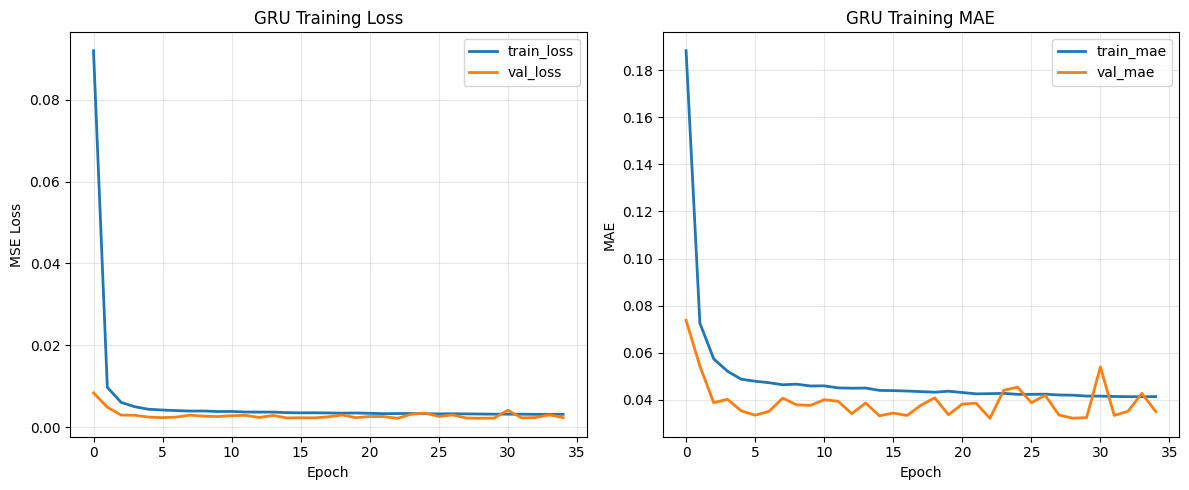

In [25]:
# Plot Training History
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train_loss", linewidth=2)
plt.plot(history.history["val_loss"], label="val_loss", linewidth=2)
plt.title("GRU Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="train_mae", linewidth=2)
plt.plot(history.history["val_mae"], label="val_mae", linewidth=2)
plt.title("GRU Training MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# Evaluate on Test Set
y_pred_scaled = model.predict(X_test)

# Inverse-transform function
def inverse_transform_sequence(y_scaled, scaler):
    y_scaled_flat = y_scaled.flatten().reshape(-1, 1)
    y_real = scaler.inverse_transform(y_scaled_flat)
    return y_real.reshape(y_scaled.shape)

y_pred = inverse_transform_sequence(y_pred_scaled, scaler)
y_real = inverse_transform_sequence(y_test, scaler)

278/278 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


In [32]:
# Calculate metrics
n_steps = y_real.shape[1]

print("GRU MODEL RESULTS")

for step in range(n_steps):
    rmse_step = np.sqrt(np.mean((y_real[:, step] - y_pred[:, step])**2))
    mae_step  = np.mean(np.abs(y_real[:, step] - y_pred[:, step]))
    mape_step = np.mean(np.abs((y_real[:, step] - y_pred[:, step]) / y_real[:, step])) * 100
    accuracy_step = 100 - mape_step

    print(f"\nStep {step+1} ({15*step + 15} min ahead):")
    print(f"  RMSE : {rmse_step:.2f} mg/dL")
    print(f"  MAE  : {mae_step:.2f} mg/dL")
    print(f"  MAPE : {mape_step:.2f} %")
    print(f"  Accuracy: {accuracy_step:.2f} %")


GRU MODEL RESULTS

Step 1 (15 min ahead):
  RMSE : 8.29 mg/dL
  MAE  : 6.18 mg/dL
  MAPE : 4.26 %
  Accuracy: 95.74 %

Step 2 (30 min ahead):
  RMSE : 16.80 mg/dL
  MAE  : 12.35 mg/dL
  MAPE : 8.25 %
  Accuracy: 91.75 %

Step 3 (45 min ahead):
  RMSE : 24.30 mg/dL
  MAE  : 17.87 mg/dL
  MAPE : 11.95 %
  Accuracy: 88.05 %

Step 4 (60 min ahead):
  RMSE : 30.36 mg/dL
  MAE  : 22.71 mg/dL
  MAPE : 15.42 %
  Accuracy: 84.58 %


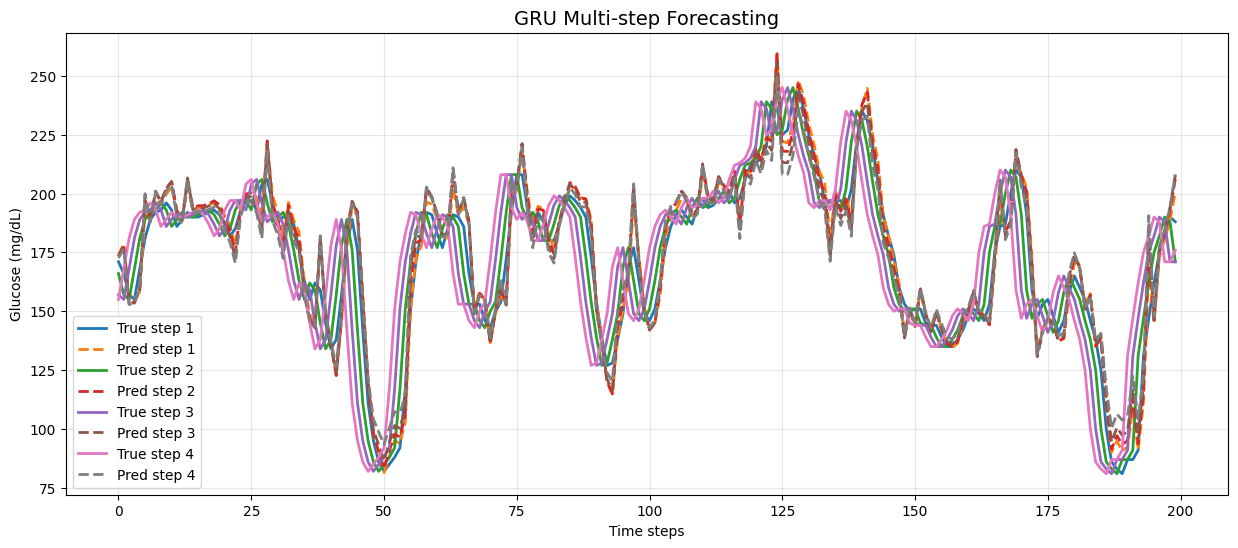

In [28]:
# Plot multi-step predictions
n_plot = 200
plt.figure(figsize=(15, 6))

for step in range(n_steps):
    plt.plot(y_real[:n_plot, step], label=f"True step {step+1}", linewidth=2)
    plt.plot(y_pred[:n_plot, step], linestyle="--", label=f"Pred step {step+1}", linewidth=2)

plt.title("GRU Multi-step Forecasting", fontsize=14)
plt.xlabel("Time steps")
plt.ylabel("Glucose (mg/dL)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
# 15-min ahead analysis
y_real_15 = y_real[:, 0]
y_pred_15 = y_pred[:, 0]

rmse = np.sqrt(np.mean((y_real_15 - y_pred_15)**2))
mae = np.mean(np.abs(y_real_15 - y_pred_15))
mape = np.mean(np.abs((y_real_15 - y_pred_15) / y_real_15)) * 100
accuracy = 100 - mape

print("15-MINUTE AHEAD PREDICTION")
print(f"RMSE: {rmse:.2f} mg/dL")
print(f"MAE:  {mae:.2f} mg/dL")
print(f"MAPE: {mape:.2f} %")
print(f"Accuracy: {accuracy:.2f} %")

15-MINUTE AHEAD PREDICTION
RMSE: 8.29 mg/dL
MAE:  6.18 mg/dL
MAPE: 4.26 %
Accuracy: 95.74 %


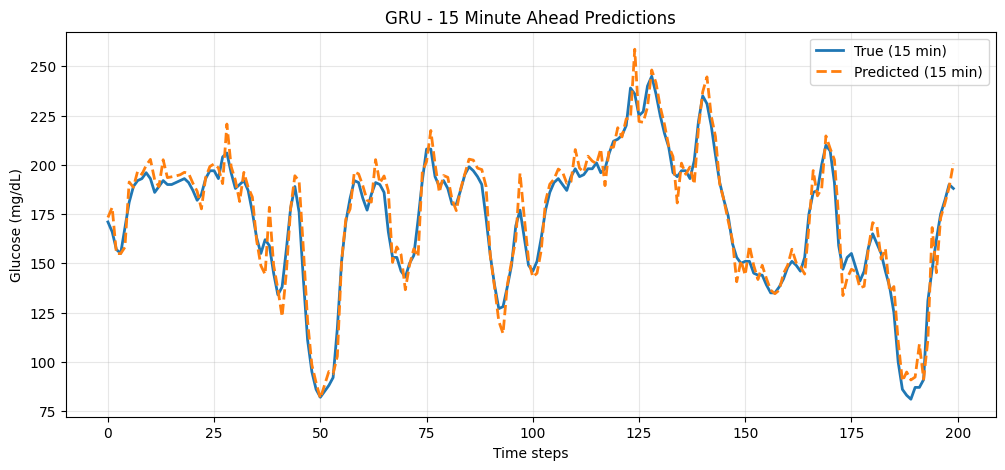

In [30]:
# Plot 15-min predictions
plt.figure(figsize=(12, 5))
plt.plot(y_real[:200, 0], label="True (15 min)", linewidth=2)
plt.plot(y_pred[:200, 0], linestyle="--", label="Predicted (15 min)", linewidth=2)
plt.title("GRU - 15 Minute Ahead Predictions")
plt.xlabel("Time steps")
plt.ylabel("Glucose (mg/dL)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()